In [6]:
# Import libraries 
from langchain_groq import ChatGroq 
from langchain_core.messages import BaseMessage, SystemMessage, HumanMessage
from langchain_core.prompts import ChatPromptTemplate

from langgraph.graph import StateGraph, START, END 
from typing import TypedDict, Annotated, Literal 
from langgraph.graph.message import add_messages 
from langgraph.checkpoint.memory import InMemorySaver 

from pydantic import BaseModel, Field
from dotenv import load_dotenv 
load_dotenv()

True

In [2]:
# Define llm
llm = ChatGroq(model="openai/gpt-oss-120b",temperature=0.6)

In [35]:

# Define classifier output
class QuestionCategory(BaseModel):
    category: Literal[
        "score advice",
        "lifestyle advice",
        "general advice"
    ]


# Create structured classifier LLM
classifier_llm = llm.with_structured_output(QuestionCategory)


# Define state
class ChatState(TypedDict):

    # Conversation messages
    messages: Annotated[list[BaseMessage], add_messages]

    # Predicted mental health score
    mental_health_score: float

    # Original user data
    user_data: dict

    # Category of user question
    question_category: Literal[
        "score advice",
        "lifestyle advice",
        "general advice"
    ]

    # Analysis of predicted score
    score_analysis: str

    # Context generated by advisor
    advisor_context: str

    # Final response
    response: str


# Create prediction analyzer node
def analyze_prediction(state: ChatState):
    """Analyze the predicted mental health score."""

    # Fetch predicted score
    score = state["mental_health_score"]

    # Analyze score
    if score < 5:
        message = "Your predicted score is relatively low."
    elif score < 7:
        message = "Your predicted score is in the moderate range."
    else:
        message = "Your predicted score is relatively high."

    # Return state update
    return {
        "score_analysis": message
    }


# Create question classifier node
def classify_question(state: ChatState):
    """Classify the user's question."""

    # Fetch conversation
    messages = state["messages"]

    # Create classification prompt
    prompt = f"""
    Classify the user's latest question into exactly one category:

    - score advice
    - lifestyle advice
    - general advice

    Conversation:
    {messages}
    """

    # Get structured category from LLM
    result = classifier_llm.invoke(prompt)

    # Return state update
    return {
        "question_category": result.category
    }


# Create question routing function
def route_question(state: ChatState) -> Literal["score_advisor", "lifestyle_advisor", "general_advisor"]:
    """Route the question to the correct advisor."""

    # Fetch question category
    category = state["question_category"]

    if category == "score advice":
        return "score_advisor"

    elif category == "lifestyle advice":
        return "lifestyle_advisor"

    else:
        return "general_advisor"


# Create score advisor node
def score_advisor(state: ChatState):
    """Create context for mental health score questions."""

    # Fetch required information
    messages = state["messages"]
    score = state["mental_health_score"]
    user_data = state["user_data"]

    # Create advisor prompt
    prompt = f"""
    You are a mental health score advisor.

    Analyze the user's question using:
    Mental health score: {score}
    User data: {user_data}
    User question: {messages}

    Provide useful context that another LLM can use
    to answer the user's question.

    Do not diagnose medical conditions or provide medical advice.
    """

    # Generate advisor context
    context = llm.invoke(prompt).content

    # Return state update
    return {
        "advisor_context": context
    }


# Create lifestyle advisor node
def lifestyle_advisor(state: ChatState):
    """Create context for lifestyle questions."""

    # Fetch required information
    messages = state["messages"]
    user_data = state["user_data"]

    # Create advisor prompt
    prompt = f"""
    You are a mental health lifestyle advisor.

    Analyze the user's question using:
    User data: {user_data}
    User question: {messages}

    Provide practical lifestyle-related context
    that another LLM can use to answer the question.

    Do not diagnose medical conditions or provide medical advice.
    """

    # Generate advisor context
    context = llm.invoke(prompt).content

    # Return state update
    return {
        "advisor_context": context
    }


# Create general advisor node
def general_advisor(state: ChatState):
    """Create context for general questions."""

    # Fetch user question
    messages = state["messages"]

    # Create advisor prompt
    prompt = f"""
    You are a helpful assistant handling general questions.

    User question:
    {messages}

    Provide useful context that another LLM can use
    to answer the user's question.
    """

    # Generate advisor context
    context = llm.invoke(prompt).content

    # Return state update
    return {
        "advisor_context": context
    }


# Create final guidance generator node
def generate_guidance(state: ChatState):
    """Generate the final personalized response."""

    # Fetch required information
    messages = state["messages"]
    score = state["mental_health_score"]
    user_data = state["user_data"]
    score_analysis = state["score_analysis"]
    advisor_context = state["advisor_context"]

    # Create final response prompt
    prompt = [
        SystemMessage(content=f"""
        You are MindWell, a supportive mental-health
        lifestyle assistant and coach for students.

        Use the following information to answer the user:

        Mental health score:
        {score}

        User data:
        {user_data}

        Score analysis:
        {score_analysis}

        Advisor context:
        {advisor_context}

        Give a short, practical and supportive response.

        If the user provides their name, use their name
        naturally in the response.

        Do not diagnose medical conditions.
        Do not provide medical advice.
        """),
        *messages
    ]

    # Generate final response
    response = llm.invoke(prompt)

    # Return final state update
    return {
        "response": response.content,
        "messages": [response]
    }


In [4]:
# Create analyzer node 
def analyze_prediction(state:ChatState): 
    """Analyze the predicted score from the ml model"""
    score = state['mental_health_score']

    if score < 5:
        message = "Your predicted score is relatively low."
    elif score < 7:
        message = "Your predicted score is in the moderate range."
    else:
        message = "Your predicted score is relatively high."

    # Return the state updates
    return {
        "response": message
    }

# Create guidence generator node 
def generate_guidance(state:ChatState):
    """Generate personalized guidance based on the predicted score"""

    messages = state['messages']
    score = state['mental_health_score']
    user_data = state['user_data']
    response = state['response']

    prompt = [SystemMessage(content=f"""
    You are MindWell, a supportive mental-health lifestyle assistant and a coach,
    who help to students in maintaing thier mental health based on some inputs.
    You give mental health guidance based on a User Data, A Mental Health Score predicted by a Machine Learning Model and a Analysis.
    You are not a doctor, you will not give medical advices or related statements.
    If user provide his/her name, start the conversation with his/her name - 
    example: name: Ashish, AIMessage: Hey Ashish, your mental health score is very good.........

    Predicted mental health score: {score}
    User data: {user_data}
    Analysis: {response}

    Give a short, practical and supportive response.
    Do not diagnose medical conditions or provide medical advice.
    """),
    *messages]

    response = llm.invoke(prompt)

    return {
        "response":response.content,
        "messages":[response]}


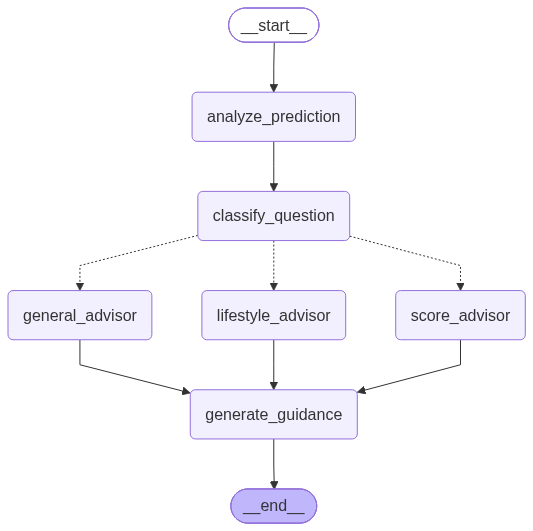

In [36]:

# Define graph
graph = StateGraph(ChatState)


# Add nodes
graph.add_node("analyze_prediction", analyze_prediction)
graph.add_node("classify_question", classify_question)
graph.add_node("score_advisor", score_advisor)
graph.add_node("lifestyle_advisor", lifestyle_advisor)
graph.add_node("general_advisor", general_advisor)
graph.add_node("generate_guidance", generate_guidance)


# Add edges
graph.add_edge(START, "analyze_prediction")
graph.add_edge("analyze_prediction", "classify_question")
graph.add_conditional_edges("classify_question",route_question)
graph.add_edge("score_advisor", "generate_guidance")
graph.add_edge("lifestyle_advisor", "generate_guidance")
graph.add_edge("general_advisor", "generate_guidance")
graph.add_edge("generate_guidance", END)

# Create checkpoint
checkpoint = InMemorySaver()

# Compile graph
workflow = graph.compile(checkpointer=checkpoint)

workflow

In [ ]:

result = workflow.invoke({
    "messages": [
        HumanMessage(content="How can I improve my mental health score?")
    ],
    "mental_health_score": 6.2,
    "user_data": {
        "Age": 21,
        "Sleep_Hours_Per_Night": 7.5,
        "Study_Hours": 5.0,
        "Physical_Activity_Hours": 2.0,
        "Avg_Daily_Usage_Hours": 4.0,
        "Daily_Unlocks": 120,
        "Stress_Level": "Medium"
    },
    "question_category": "",
    "score_analysis": "",
    "advisor_context": "",
    "response": ""
},config={"configurable":{'thread_id':1}})

result

{'messages': [HumanMessage(content='How can I improve my mental health score?', additional_kwargs={}, response_metadata={}, id='a76878ac-9911-4523-a9c9-bcae93e1d250'), AIMessage(content='Hey there! Based on what I see—7½\u202fh of sleep, 2\u202fh of daily exercise, and a moderate stress level—you’re already doing a lot of the right things. A few small tweaks can help push your mental‑health score higher:\n\n**1. Tame the screen‑time spikes**  \n-\u202fDo a quick audit of the apps you unlock most (you’re at ~120 unlocks a day).  \n-\u202fSet daily limits for the top 2–3 “non‑essential” apps (e.g., 30\u202fmin for social media, 45\u202fmin for streaming).  \n-\u202fCreate a “no‑phone” window the first hour after you wake up and the last hour before bed—use that time for a short stretch, a book, or a mindfulness practice.\n\n**2. Structure study with breaks**  \n-\u202fTry the Pomodoro method: 25\u202fmin focused study → 5\u202fmin movement break (stand, stretch, walk).  \n-\u202fEvery 45

In [40]:
result

{'messages': [HumanMessage(content='How can I improve my mental health score?', additional_kwargs={}, response_metadata={}, id='a76878ac-9911-4523-a9c9-bcae93e1d250'),
  AIMessage(content='Hey there! Based on what I see—7½\u202fh of sleep, 2\u202fh of daily exercise, and a moderate stress level—you’re already doing a lot of the right things. A few small tweaks can help push your mental‑health score higher:\n\n**1. Tame the screen‑time spikes**  \n-\u202fDo a quick audit of the apps you unlock most (you’re at ~120 unlocks a day).  \n-\u202fSet daily limits for the top 2–3 “non‑essential” apps (e.g., 30\u202fmin for social media, 45\u202fmin for streaming).  \n-\u202fCreate a “no‑phone” window the first hour after you wake up and the last hour before bed—use that time for a short stretch, a book, or a mindfulness practice.\n\n**2. Structure study with breaks**  \n-\u202fTry the Pomodoro method: 25\u202fmin focused study → 5\u202fmin movement break (stand, stretch, walk).  \n-\u202fEvery 

In [ ]:

result = workflow.invoke({
    "messages": [
        HumanMessage(content="?")
    ],
    "mental_health_score": 6.2,
    "user_data": {
        "Age": 21,
        "Sleep_Hours_Per_Night": 7.5,
        "Study_Hours": 5.0,
        "Physical_Activity_Hours": 2.0,
        "Avg_Daily_Usage_Hours": 4.0,
        "Daily_Unlocks": 120,
        "Stress_Level": "Medium"
    },
    "question_category": "",
    "score_analysis": "",
    "advisor_context": "",
    "response": ""
},config={"configurable":{'thread_id':1}})

result